# Classification Model Using Scikit-learn

## 1. Introduction
In this notebook, I explore the Titanic dataset and build a binary classification model to predict passenger survival.

The notebook is structured as follows:

1. Load and inspect the dataset
2. Create summary statistics and visualizations
3. Define features and target
4. Train a logistic regression model with scikit-learn
5. Evaluate the model using classification metrics

## 2. Load dataset

In [4]:
import pandas as pd

data = pd.read_csv("../data/titanic.csv")
data.head()  #check the first 5 lines

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


## 3. Exploration
### 3.1 Inspect dataset

In [10]:
data.columns  #to get all features

Index(['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class',
       '3rd_class', 'survived'],
      dtype='str')

In [11]:
data.shape  #check the size of the data

(887, 8)

In [12]:
data.info()  #check missing values

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


### 3.2 Data summaries

In [13]:
data.describe() #statistical data

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


In [14]:
data["survived"].value_counts() #show number of each target class.

survived
0    545
1    342
Name: count, dtype: int64

In [15]:
data["survived"].value_counts(normalize=True) #show percentage of each target class.

survived
0    0.614431
1    0.385569
Name: proportion, dtype: float64

#### Observation
1. No missing values;
2. About 38.6% of passengers survived. The target classes are not perfectly balanced.
3. The average passenger age is about 29.5 years, and the median age is 28 years.
4. Most passengers paid relatively low fares, but a few passengers paid much higher fares.
5. Around 54.9% of passengers are in third class.

## 4. EDA/Visualizations

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

### 4.1 Target distribution

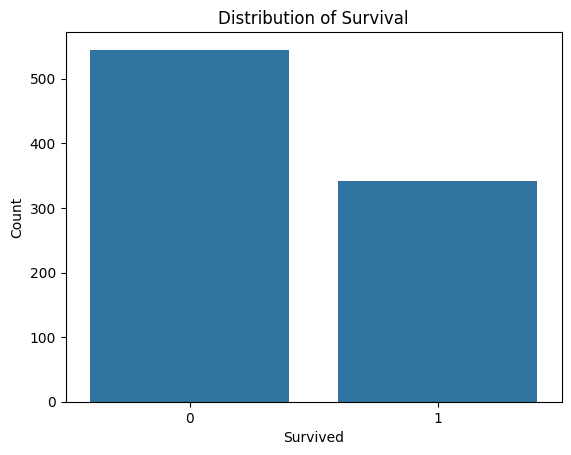

In [17]:
sns.countplot(data=data, x="survived")  
plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

#### Observation
The count plot helps check whether the two classes are balanced or imbalanced.<br>
It shows that more passengers did not survive than survived. Therefore, accuracy alone may not be enough to evaluate the model later.

### 4.2 Survival by sex

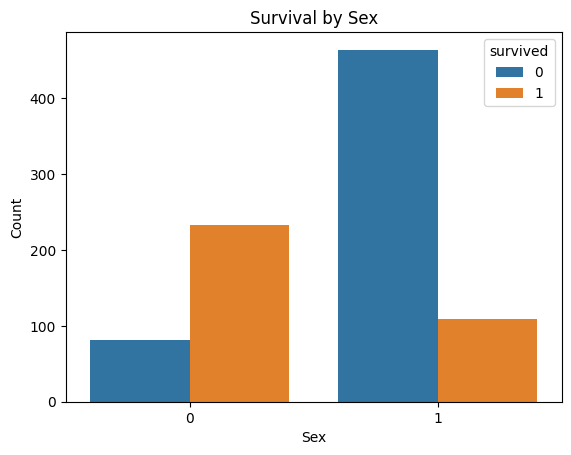

In [18]:
sns.countplot(data=data, x="sex", hue="survived")
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [19]:
data.groupby("sex")["survived"].mean() #Survival rate by sex

sex
0    0.742038
1    0.190227
Name: survived, dtype: float64

#### Observation


The plot shows the relationship between sex and survived.<br>
It suggests that survival differs strongly between the two encoded sex groups.<br>
The groupby result shows the survival rate for each encoded sex group. This helps confirm that `sex` could be an important feature for predicting survival.

### 4.3 Age distribution by survival

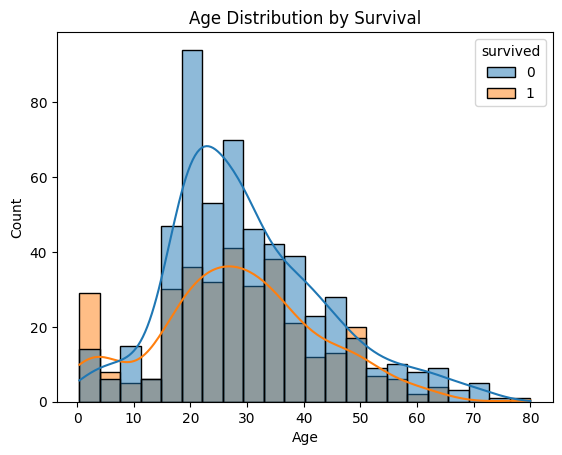

In [20]:
sns.histplot(data=data, x="age", hue="survived", kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Observation
This histoplot is suitable here because `age` is a numerical variable.<br>
The plot shows whether survival patterns differ across age groups, for example between children, adults, and older passengers.

### 4.4 Fare distribution

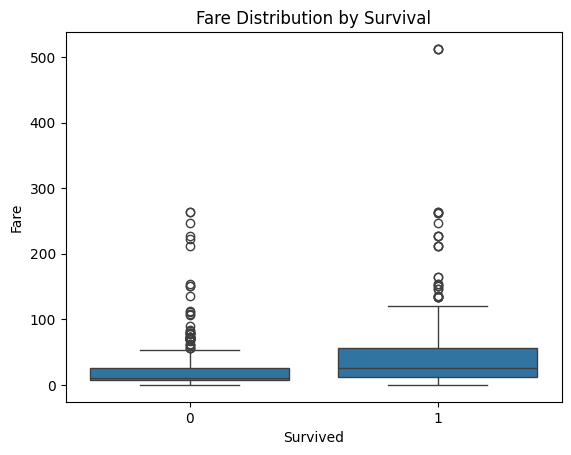

In [5]:
sns.boxplot(data=data, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

### Observation
This boxplot compares the fare distribution between passengers who survived and passengers who did not survive. <br> 
It is useful here because `fare` is a numerical variable and contains possible outliers.<br>
The plot shows that some passengers paid much higher fares than most others. <br>
Fare may be related to survival because it can reflect passenger class or cabin location.

### 4.5 Survival by passenger class

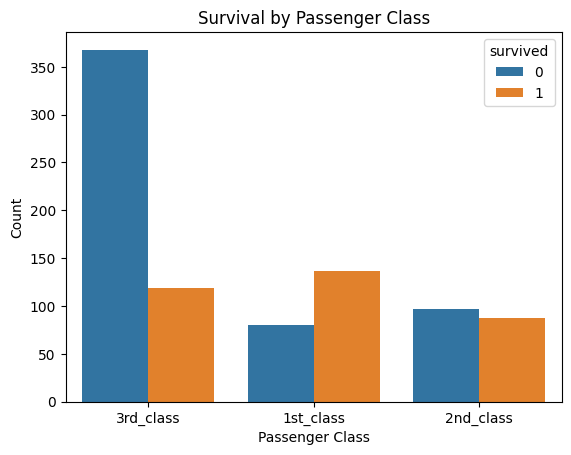

In [6]:
data_plot = data.copy()

data_plot["passenger_class"] = data_plot[["1st_class", "2nd_class", "3rd_class"]].idxmax(axis=1) 

sns.countplot(data=data_plot, x="passenger_class", hue="survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

In [7]:
data_plot.groupby("passenger_class")["survived"].mean() #Survival rate by class

passenger_class
1st_class    0.629630
2nd_class    0.472826
3rd_class    0.244353
Name: survived, dtype: float64

#### Observation
This count plot shows the relationship between passenger class and survival. <br> 
The survival rates by class suggest that passenger class is likely an important feature for predicting survival.

## 5. Model training
### 5.1 Define features and target

In [8]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"

features = data[FEATURES] ##take out the specific columns and make a new table
features.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class
0,1,22.0,1,7.2500,0,0,1
1,0,38.0,1,71.2833,1,0,0
2,0,26.0,0,7.9250,0,0,1
3,0,35.0,1,53.1000,1,0,0
4,1,35.0,0,8.0500,0,0,1


In [9]:
target = data[TARGET]
target.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

## 5.2 Prepare dataset
The dataset is split into a training set and a test set.<br>
The training set is used to train the model, while the test set is kept unseen and used later to evaluate the model.  

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
) 
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


`test_size=0.2` means 20% is used as the test set and 80% is used as the training set.<br>
`random_state=42` makes the split reproducible, so the same rows are selected each time the notebook is run.

## 5.3 Train Logistic Regression with scikit-learn

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) #model init
model.fit(X_train, y_train) #model training

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
y_pred = model.predict(X_test) # let trained model to predict base on the features in test dataset
y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [14]:
y_proba = model.predict_proba(X_test)
# print(y_proba) # probability for each passenger
y_proba[:, 1] # print only class 1(Survived)

array([0.32040285, 0.17168984, 0.02641529, 0.25941956, 0.12339733,
       0.69114681, 0.08421311, 0.12396557, 0.64310308, 0.61552109,
       0.42405889, 0.71898906, 0.49631655, 0.04907053, 0.48513262,
       0.21212148, 0.04759193, 0.91768787, 0.16037345, 0.13739947,
       0.08383487, 0.13004277, 0.6765361 , 0.30278207, 0.28854644,
       0.37397328, 0.16956501, 0.18584866, 0.08279484, 0.48864436,
       0.69081939, 0.20916195, 0.82922794, 0.65150378, 0.49954907,
       0.11645258, 0.08992088, 0.41532994, 0.87935505, 0.77409978,
       0.13700115, 0.02681343, 0.85461787, 0.1319623 , 0.29274511,
       0.06039528, 0.08320086, 0.11267417, 0.08555764, 0.09603029,
       0.03190812, 0.07205125, 0.1402358 , 0.07870982, 0.36316945,
       0.230534  , 0.33563912, 0.11237693, 0.92455437, 0.1356804 ,
       0.20033874, 0.68325855, 0.08993307, 0.83412804, 0.4445205 ,
       0.13256167, 0.12825955, 0.7679881 , 0.09596203, 0.34960552,
       0.13612229, 0.95060315, 0.33172627, 0.10914023, 0.13618

## 6. Evaluate model

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

### 6.1 Accuracy

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7303370786516854


The model achieved an accuracy of about 73.03%, meaning that approximately 73% of the test data was predicted correctly. 

### 6.2 Precision

In [17]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7021276595744681


The precision is about 70.21%, so when the model predicts a passenger as survived, the prediction is correct about 70% of the time.  

### 6.3 Recall

In [18]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.4925373134328358


The recall is only about 49.25%, which means Among the passengers who actually survived, only about 49% were correctly recognized by the model. <br>
So the model missed about half of the actual survivors.

### 6.4 F1-score

In [19]:
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

F1-score: 0.5789473684210527


The F1-score is about 57.89%. Since the recall is relatively low, the F1-score is also not very high.<br>
It means that the model is relatively careful when predicting survival, but it does not identify enough actual survivors.

### 6.5 Confusion matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[97 14]
 [34 33]]


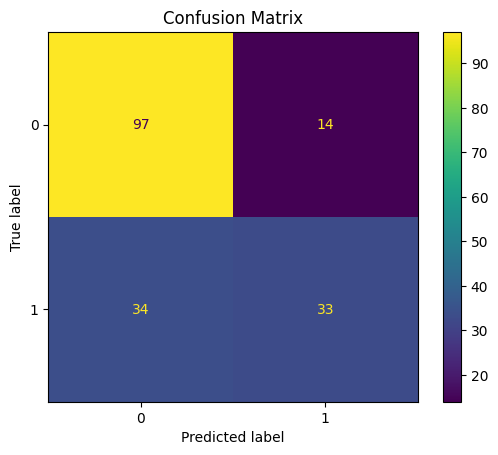

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

There are 97 true negatives and 33 true positives. It means 97 passengers were correctly predicted as not survived and 33 passengers were correctly predicted as survived.<br>

There are also 14 false positives and 34 false negatives, which means 14 passengers were predicted as survived but actually did not survive, and 34 passengers actually survived but were predicted as not survived.<br>

The model missed many actual survivors. Overall, the model performs better at identifying passengers who did not survive than passengers who survived.

### 6.6 Classification report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80       111
           1       0.70      0.49      0.58        67

    accuracy                           0.73       178
   macro avg       0.72      0.68      0.69       178
weighted avg       0.73      0.73      0.72       178



In [43]:
# try different threshold
threshold = 0.4
y_pred_try = (y_proba_survived >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, y_pred_try))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_try))

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       111
           1       0.74      0.63      0.68        67

    accuracy                           0.78       178
   macro avg       0.77      0.75      0.75       178
weighted avg       0.77      0.78      0.77       178

Confusion Matrix:
[[96 15]
 [25 42]]


### 6.7 ROC-AUC

In [45]:
y_proba_survived = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba_survived)
print("Classifier (AUC) = :", roc_auc)

Classifier (AUC) = : 0.8150463896732554


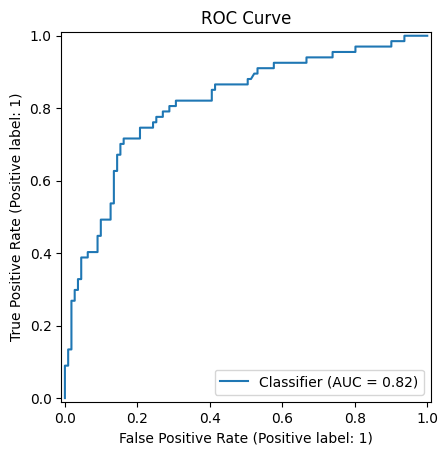

In [47]:
RocCurveDisplay.from_predictions(y_test, y_proba_survived)
plt.title("ROC Curve")
plt.show()

The ROC-AUC score shows that the model has a good ability to separate survived and not-survived passengers based on predicted probabilities. <br>
This means the probability ranking is useful, even though the default threshold of 0.5 gives a relatively low recall.

## 7. Conclusion

In this notebook, I used a Logistic Regression model to predict whether a passenger survived the Titanic disaster.

The dataset has no missing values, and about 38.6% of the passengers survived, so the target classes are not perfectly balanced.

The model has moderate overall accuracy, and its precision is acceptable, but the recall is relatively low. This means the model is better at making reliable positive predictions than at finding all actual survivors.

Overall, Logistic Regression is a good model for the task. The model has moderate performance, but its main limitation is the low recall. A possible next step would be to adjust the decision threshold or compare Logistic Regression with other classification models.